# Inpainting

## Problem Setting

Inpainting problems fill the missing parts of an image by using the semantic information and texture from the surrounding visible context. The goal is to reconstruct the missing pixels so that the completed image is close to the original.

One approach is to treat this problem as a supervised image-to-image regression task. 

For each clean RGB image $𝑥$, we create a corrupted input by applying a binary mask $M$ that hides a contiguous rectangular region.

Under a shared training and evaluation protocol, three baselines are compared: (1) non-learning PDE-based inpainting methods, (2) a simple encoder–decoder autoencoder without skip connections, and (3) an improved U-Net-like architecture designed to better preserve spatial detail.


## Formal Definition
Let $x \in \mathbb{R}^{H \times W \times C}$ be a clean image with height $H$, width $W$ and $C = 3$ color channels. 
We define a **binary mask**  $M \in \{0,1\}^{H \times W}$ that determines which parts of the image are visible. The values of the mask are denoted as 
$$
M_{i,j} =
\begin{cases}
1 & \text{if pixel } (i,j) \text{ is visible (known)} \\
0 & \text{if pixel } (i,j) \text{ is missing}
\end{cases}
$$

The corrupted **input image** $x_{\text{masked}}$ is generated by applying the mask to the original image:
$$x_{\text{masked}} = M \odot x,$$
where $\odot$ denotes element-wise multiplication (Hadamard product) and the mask is broadcast over channels. 
This results to pixel values equal zero in the missing regions (where $M=0$). 

The **learning task** is to train a function $f_\theta$ that reconstructs the original image $x$ from the masked input $x_{\text{masked}}$ and mask $M$:
$$\hat{x} = f_\theta(x_{\text{masked}}, M)$$
where $\hat{x}$ represents the reconstructed output image.

During training the distance-based loss $L$ between the prediction $\hat{x}$ and the ground truth image $x$ is minimzed:
$$
\theta^{*} \;=\; \arg\min_{\theta}\, L\!\big(f_{\theta}(x_{\text{masked}}, M),\, x\big)
$$
To assess the inpainting quality the loss $L$ is computed exclusively on the missing region using $(1−M)$, so the model is rewarded for reconstruction rather than copying known pixels.
$$
L_{\text{miss}} \;=\;
\frac{\sum \left| \hat{x} - x \right|\,(1 - M)}
{\sum (1 - M)}
$$

### Dataset and Dataset Split
For this task **Places365** (v2) has been used which consists of high-resolution photographs covering a wide variety of indoor and outdoor scenes (e.g., landscapes, buildings, rooms)

It has higher resolution than e.g. CIFAR10 and unlike basic datasets (e.g. MNIST) it contains complex natural textures. This makes the inpainting task not trivial, since it forces the model to actually learn meaningful structural representations and texture rather than simple geometric interpolation.

At the same time the scenes contain repetitive structure which allows the model to converge within reasonable computational limits. Furthermore, due to this reason, the models are only trained on a **small subset** of the official **validation split**. The validation split was chosen intentionally as it contains clean high-quality samples. 


# Environment Setup

Before any data is loaded, the notebook determines where it is running and sets the
relevant paths accordingly, so the same code works across Kaggle, Colab, and a local
machine without manual editing.

In [1]:
from enum import Enum
from pathlib import Path
import sys
import os

class Runtime(Enum):
    KAGGLE = "kaggle"
    COLAB  = "colab"
    LOCAL  = "local"

class Mode(Enum):
    DEV  = "dev"
    PROD = "prod"

MODE = Mode.DEV

def detect_runtime() -> Runtime:
    if Path("/kaggle/input").exists() and Path("/kaggle/working").exists():
        return Runtime.KAGGLE
    elif "google.colab" in sys.modules:
        return Runtime.COLAB
    else:
        return Runtime.LOCAL

RUNTIME = detect_runtime()
print("[setup] MODE:", MODE.value, "| RUNTIME:", RUNTIME.value)

[setup] MODE: dev | RUNTIME: kaggle


In [2]:
HF_DATASET = "mmarschn/inpainting_validPlaces"  
HF_CHECKPOINTS   = "mmarschn/inpainting_checkpoints" 

In [3]:
import os
from pathlib import Path

_MARKERS = (".git", "pyproject.toml", "requirements.txt", "setup.cfg")

def find_repo_root(start: Path | None = None) -> Path:
    """
    Find the repository root by walking upwards looking for marker files.
    """
    env = os.getenv("CODE_ROOT")
    if env:
        p = Path(env).expanduser().resolve()
        if not p.exists():
            raise FileNotFoundError(f"CODE_ROOT is set but does not exist: {p}")
        return p

    cur = (start or Path.cwd()).resolve()
    for parent in (cur, *cur.parents):
        if any((parent / m).exists() for m in _MARKERS):
            return parent

    # last resort: cwd
    return cur

In [4]:
CODE_ROOT = find_repo_root()
print(CODE_ROOT)

/


In [5]:
if RUNTIME == Runtime.COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    os.environ["CODE_ROOT"] = "/content/drive/MyDrive/inpainting"

# Setup

The setup fixes the run configuration and imports the required libraries. The core hyperparameters and constants are defined so that experiments are easy to reproduce and compare.

For reproducibility, all random seeds are fixed, and the DataLoaders later use a single worker. Weights & Biases is used for experiment tracking and is authenticated here when running in a non-local
environment.

In [6]:

from pathlib import Path
import sys

os.environ["PYTHONHASHSEED"] = "51"

In [7]:
def setup_environment():

    if RUNTIME == Runtime.KAGGLE:
        # set paths
        CODE_ROOT = Path("/kaggle/input/datasets/mmarschn/inpainting")
        DATA_DIR = Path("/kaggle/input/datasets/mmarschn/places2-val-256/val_256")
        WORK_ROOT = Path("/kaggle/working/inpainting")
        WORK_ROOT.mkdir(parents=True, exist_ok=True)
        CHECKPOINTS_DIR = Path("/kaggle/working/inpainting_checkpoints")
        CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
        
        os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

        # set environment variables: load from kaggle secrets
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")


    elif RUNTIME == Runtime.COLAB:
        ## mount drive
        ## 
        CODE_ROOT = Path("/kaggle/input/inpainting")
        DATA_DIR = Path("/kaggle/input/places2-val-256/val_256")
        WORK_ROOT = Path("/kaggle/working/inpainting")
        WORK_ROOT.mkdir(parents=True, exist_ok=True)
        CHECKPOINTS_DIR = Path("/kaggle/working/inpainting_checkpoints")

    else:
        # set paths
        ROOT = Path.cwd().parents[0]        # sets project url as root url
        # Dataset root (can be outside the repo)
        CODE_ROOT = ROOT
        DATA_ROOT = Path(os.getenv("DATA_DIR", ROOT / "data"))
        DATA_DIR = DATA_ROOT / "inpainting/places2/val_256"
        WORK_ROOT = ROOT
        CHECKPOINTS_DIR = ROOT / "checkpoints"
        CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

        # set environment variables
        from dotenv import load_dotenv
        load_dotenv()


    sys.path.insert(0, str(CODE_ROOT / "src"))      # allow Python to import modules from the project's src/ directory

    return DATA_DIR, CHECKPOINTS_DIR, CODE_ROOT, WORK_ROOT

In [74]:
DATA_DIR, CHECKPOINTS_DIR, CODE_ROOT, WORK_ROOT = setup_environment()

print(
    f"[env] CODE_ROOT={CODE_ROOT}\n"
    f"[env] DATA_DIR={DATA_DIR}\n"
    f"[env] WORK_ROOT={WORK_ROOT}\n"
    f"[env] CHECKPOINTS_DIR={CHECKPOINTS_DIR}"
)

img_dir = WORK_ROOT / "img"
img_dir.mkdir(parents=True, exist_ok=True)

[env] CODE_ROOT=/kaggle/input/datasets/mmarschn/inpainting
[env] DATA_DIR=/kaggle/input/datasets/mmarschn/places2-val-256/val_256
[env] WORK_ROOT=/kaggle/working/inpainting
[env] CHECKPOINTS_DIR=/kaggle/working/inpainting_checkpoints


In [9]:
# Install dependencies
%cd $CODE_ROOT
try:
    import torch
except ImportError:
    %pip install --no-cache-dir -r requirements.txt

/kaggle/input/datasets/mmarschn/inpainting


In [94]:
# Imports
import torch
import torchvision.transforms.v2 as transforms
from torch.utils.data import Dataset, Subset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
import numpy as np

from PIL import Image
from typing import Optional, Tuple
import math
import random
import time
import json

import matplotlib.pyplot as plt
from tqdm import tqdm

import wandb

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")


#from config import (DEVICE, NUM_WORKERS, SEED, PROJECT_ROOT, CHECKPOINTS_DIR, PLACES_DATASET_DIR) 
from utils import set_seeds, init_wandb, format_time, cleanup
from visualization import show_dataset_grid, show_img_grid, plot_losses, plot_tuning_curves


In [72]:
# Constants

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0     # easier to ensure reproducibility
SEED = 51

TEST_FRAC = 0.1
VAL_FRAC = 0.2

H_MASK = 70
W_MASK = 90

TEST_SAMPLE_IDX = 40              #40
NUM_DIFFUSION_ITERS=400

NUM_SAMPLES = 6000                  #2000
IMG_SIZE = 256
BATCH_SIZE = 32

TUNE_EPOCHS  = 15    # short budget for the search
FINAL_EPOCHS = 30    # full budget for the winning config
#LR = 1e-4
#BASE = 64     # 32, later 64

In [12]:
# Set random seeds for reproducibility across Python, NumPy, and PyTorch.
set_seeds(SEED)

Seeds set to 51


In [13]:
# Authenticate with Weights & Biases (W&B) to enable experiment tracking/logging.
#if RUNTIME != Runtime.LOCAL:
#    wandb.login()

# Data Loading & Split

In this section, the `Places365` images are loaded using a simple dataset that reads
RGB `.jpg` files and converts them to tensors scaled to `[0, 1]`, using only the first
`NUM_SAMPLES` images for compute reasons.

A deterministic train/val/test split is then created by shuffling the indices with a
fixed seed and wrapping them with `Subset`, ensuring that all models are trained and
evaluated on the exact same images.

In [14]:
class ImageDataset(Dataset):
    """Loads .jpg images from a folder, converts them, adds a transform and returns one image tensor per index."""
    def __init__(
        self,
        root: str,
        start_idx: int = 0,
        end_idx: Optional[int] = None,
        transform: Optional[callable] = None,
    ):
        # Root directory that contains the image files
        self.root = Path(root)

        self.transform = transform

        # Collect all .jpg/.JPG files and sort for deterministic, reproducible indexing
        files = sorted({p.resolve() for p in list(self.root.glob("*.jpg")) + list(self.root.glob("*.JPG"))})

        # Error if folder is empty / path is wrong
        if len(files) == 0:
            raise FileNotFoundError(f"No .jpg images found in {self.root}")

        # Optionally work on only a subset of the folder
        self.files = files[start_idx:end_idx]

        # Fail early if the chosen slice contains no files
        if len(self.files) == 0:
            raise ValueError("Selected subset is empty (check start_idx/end_idx)")

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> torch.Tensor:
        # Load image and force RGB
        img = Image.open(self.files[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


In [15]:
img_base_transforms = transforms.Compose([
    transforms.ToImage(),                           
    transforms.ToDtype(torch.float32, scale=True)       # scales data into [0,1]
])

# Load dataset
base_data = ImageDataset(DATA_DIR, start_idx=0, end_idx=NUM_SAMPLES, transform=img_base_transforms)

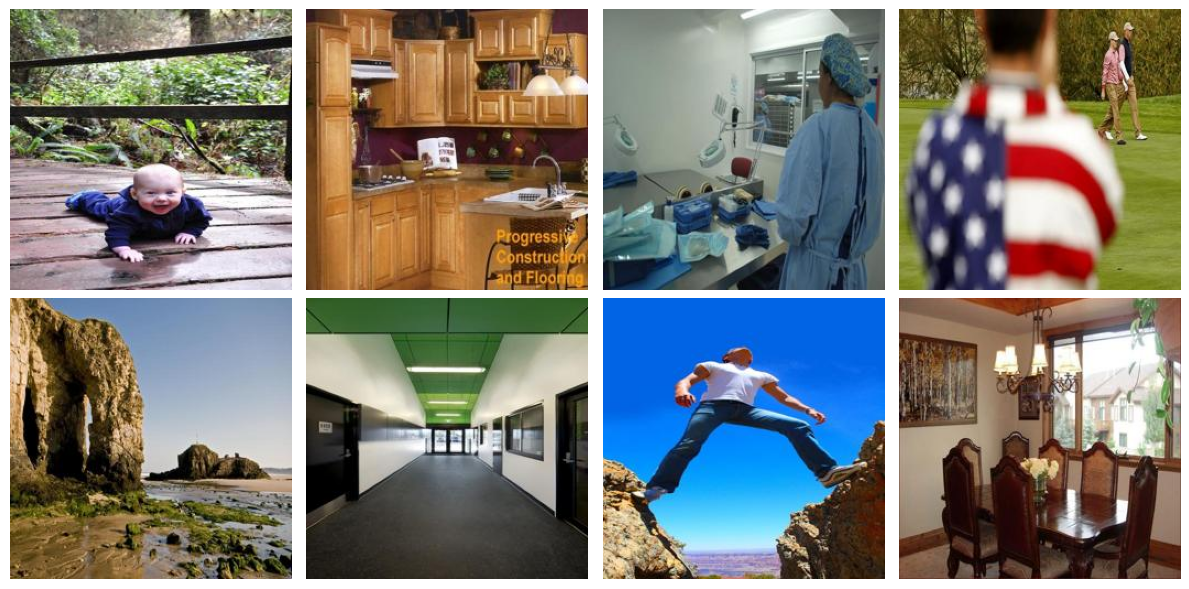

In [16]:
# Show dataset samples
fig, ax = show_dataset_grid(base_data, 8, 4)
plt.show()

In [17]:
def train_test_val_split(
    dataset,
    val_frac: float = 0.1,
    test_frac: float = 0.1,
    seed: int = 51,
) -> Tuple[Subset, Subset, Subset]:
    """Reproducibly split a dataset into train/val/test Subsets using shuffled indices and given fractions."""
    
    n = len(dataset)

    # Use a dedicated RNG with a fixed seed so the split is reproducible
    g = torch.Generator().manual_seed(seed)

    # Create a random permutation of indices
    perm = torch.randperm(n, generator=g).tolist()

    # Convert fractions into absolute split sizes
    n_val = int(round(n * val_frac))
    n_test = int(round(n * test_frac))

    # Put all remaining samples into train (guarantees train+val+test == n)
    n_train = n - n_test - n_val

    # Slice the shuffled indices into three non-overlapping sets
    train_idx = perm[:n_train]
    val_idx   = perm[n_train:n_train + n_val]
    test_idx  = perm[n_train + n_val:]

    # Wrap the original dataset with Subset views (no data is copied)
    return Subset(dataset, train_idx), Subset(dataset, val_idx), Subset(dataset, test_idx)


In [18]:
# Split the base dataset into reproducible train/validation/test subsets
train_base_data, val_base_data, test_base_data = train_test_val_split(
    base_data,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SEED
)

# Data Preprocessing

In this section, the images are preprocessed before being used for training. Since the images are already loaded as float tensors in `[0, 1]`, the main preprocessing step is
the deterministic generation of masks that define the missing regions for the inpainting
task.

Finally, we build DataLoaders where only the training loader is shuffled (still reproducibly), while validation and test loaders remain fixed to guarantee consistent evaluation.

**Note about Normalization:**

Z-score normalization is deliberately **not** applied: the inputs are bounded and homogeneous (all channels share the same `[0, 1]` range), and every convolutional block uses BatchNorm, which rescales activations internally. 

Standardization therefore offers little benefit in this setting, while keeping the data in `[0, 1]` has two concrete advantages — the mask value of `0` cleanly denotes an empty (unknown) pixel, and the reconstruction metrics (MAE, PSNR) are computed directly on interpretable pixel intensities.

## Mask generation and application

To create the inpainting task, we synthetically remove part of each image using a binary mask.

We use contiguous rectangular masks rather than masking individual random pixels. A larger connected missing region cannot be reconstructed through simple local interpolation alone and therefore requires the model to use information from the surrounding image context.

### Deterministic Mask Assignment

The position of the missing region is chosen randomly but remains fixed for each image. The random seed is derived from the image index, so the **same image receives the same mask across training epochs**.
This makes the masking process reproducible and ensures that all models are trained and evaluated on the same corrupted inputs, allowing for a fair comparison between approaches.

### Input Representation

For each image, we generate a binary mask:
$$
M \in \{0,1\}^{H \times W},
$$
where $( M_{ij} = 1)$ indicates known pixels and $( M_{ij} = 0)$ indicates a missing pixel. The corrupted image is obtained by element-wise multiplication:
$$
I_{\text{masked}} = M \odot I_{\text{original}}.
$$

In practice the mask is concatenated to the RGB input to form a 4-channel tensor of shape $(4×H×W)$. Providing the mask explicitly tells the network which pixels are observed and which pixels need to be reconstructed, avoiding ambiguity between genuinely zero-valued pixels and pixels that were removed by the masking process.

In [19]:
class InpaintingDataset(Dataset):
    """
    Wrapper dataset: applies masks on-the-fly and returns (x_in, y, mask), where
      y     = original image tensor (C,H,W)
      mask  = binary mask tensor (1,H,W), 1=visible, 0=missing
      x_in  = either masked image (C,H,W) OR concat(masked image, mask) (C+1,H,W)

    Deterministic masks: seed derived from (global_seed + idx) OR from filename hash (more robust).
    """
    def __init__(
        self,
        base: Dataset,
        h_mask: int,
        w_mask: int,
        seed: int = 51,
        # fixed_mask_per_image: bool = True,        ## later extension with random masks for.each img
    ):
        self.base = base
        self.h_mask = h_mask
        self.w_mask = w_mask
        self.seed = seed
        #self.fixed = fixed_mask_per_image          ## later extension with random masks for.each img

    def __len__(self):
        return len(self.base)
    
    def _rng_for(self, idx: int) -> random.Random:
        ## later extension with random masks for.each img
        #if not self.fixed:
        #    return random.Random()  # future extension for nondeterministic
        return random.Random(self.seed + idx)
        
    def __getitem__(self, idx: int):
        img = self.base[idx]                             # (C,H,W) tensor
        
        C, H, W = img.shape
        # ensures that mask is not bigger than the image
        h = min(self.h_mask, H)
        w = min(self.w_mask, W)

        rng = self._rng_for(idx)

        # pick top-left so rectangle stays inside image
        top = rng.randint(0, H - h)
        left = rng.randint(0, W - w)

        # create mask: 1 everywhere, 0 inside rectangle
        mask = torch.ones((1, H, W), dtype=torch.float32)
        mask[:, top:top + h, left:left + w] = 0.0

        # apply mask (broadcast over channels); Masked image = mask x original image
        masked_img = mask * img

        # includes the mask as extra channel
        x_in = torch.cat([masked_img, mask], dim=0)  # (C+1,H,W)

        return x_in, img, mask

In [20]:
train_data = InpaintingDataset(train_base_data, H_MASK, W_MASK, SEED)
val_data   = InpaintingDataset(val_base_data, H_MASK, W_MASK, SEED)
test_data  = InpaintingDataset(test_base_data, H_MASK, W_MASK, SEED)

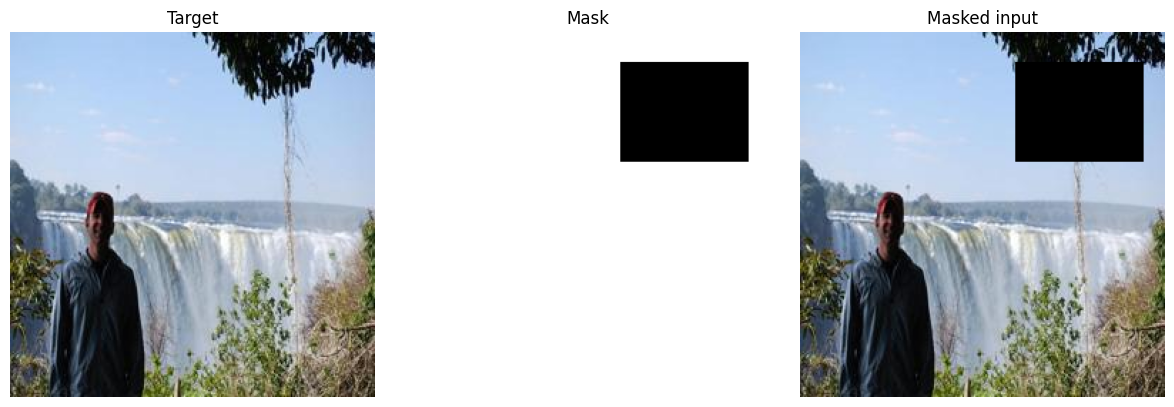

In [75]:
x_in, img, mask = test_data[TEST_SAMPLE_IDX]

fig, ax = show_img_grid(
    tensors=[img, mask, x_in],
    titles=["Target", "Mask", "Masked input"]
)
fig.savefig(img_dir / "test_sample.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  generator=g, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Evaluation Protocol

This section defines how all methods — the PDE baselines as well as the neural models — are evaluated, so that every approach is scored under one identical protocol. The metric and its aggregation are implemented once here and reused throughout.

To measure how well the model fills in missing parts, we evaluate only the masked (missing) region.

Full-image metrics are misleading here because most pixels are already known and stay unchanged. Inclusion of these known pixels would dilute the error signal, making poor reconstructions appear artificially high-quality. 

Therefore, we compute all metrics evaluating only the missing-region mask $(1 − 𝑀)$, so errors on known pixels are set to zero.

### Metrics: MAE and PSNR
We use two metrics that complement each other:

**1. Masked Mean Absolute Error (MAE):** This is the average absolute difference between the prediction and the ground truth only in the missing region. Compared to MSE, MAE is less dominated by a few large errors and often matches visual sharpness better.

For an RGB image, the masked mean absolute error (MAE) is defined as:
$$
\mathrm{MAE}_{\text{miss}} =
\frac{\sum_{i,j,c} |\hat{y}_{i,j,c} - y_{i,j,c}|\,(1 - M_{ij})}
     {C \sum_{i,j}(1 - M_{ij})}
$$

where $\hat{y}$ is the reconstructed image and $y$ is the ground truth and $(1 - M)$ is the missing-pixel indicator. 

**2. Peak Signal-to-Noise Ratio (PSNR):** PSNR is a common reconstruction metric reported in logarithmic decibel (dB). It is computed from the masked MSE but shown on a log scale. It compares the maximum possible pixel value (“signal”) to the reconstruction error (“noise”). Higher PSNR values indicate better quality.

The peak signal-to-noise ratio (PSNR) on the missing region is given by:
$$
\mathrm{PSNR}_{\text{miss}} =
10 \log_{10}\left(
\frac{\mathrm{MAX}^2}{\mathrm{MSE}_{\text{miss}} + \varepsilon}
\right)
=
10 \log_{10}\left(
\frac{1}{\mathrm{MSE}_{\text{miss}} + \varepsilon}
\right)
$$
where $\varepsilon$ is a small constant added for numerical stability. For images scaled to $[0,1]$, the maximum possible pixel value is $\mathrm{MAX} = 1$.
The masked mean squared error (MSE) is defined analogously to the masked MAE.


### Global Aggregation Strategy
In `evaluate_miss`, we compute a global pixel-weighted average: we sum the total error over all missing pixels and divide by the total number of missing pixels (and channels). We do not average per-image scores. This ensures that every missing pixel contributes equally to the final score. (With the fixed mask size used here, per-pixel and per-image averaging nearly coincide; the choice matters only if mask sizes vary.)


In [23]:
def model_predictor(model):
    """
    Wraps a model as an (x_in, mask) -> prediction predictor, so evaluate_miss
    can score models and baselines through the same path.
    """
    def predictor(x_in, mask):
        return model(x_in)  # mask already in channel 4
    return predictor

In [24]:
@torch.no_grad()
def eval_sums_miss(predictor_fn, batch, device):
    """
    Computes raw error sums in pixel space [0,1] for global evaluation.

    Returns raw sums (not per-batch averages) so metrics can be aggregated
    correctly across the entire dataset.
    """
    x_in, y, mask = batch  
    x_in, y, mask = x_in.to(device), y.to(device), mask.to(device)

    y_hat = predictor_fn(x_in, mask)
    missing = 1.0 - mask

    # ---- VAL/TEST (pixel space for reporting metrics) ----
    y_pix = y.clamp(0, 1)           
    yhat_pix = y_hat.clamp(0, 1)

    abs_err_pix = (yhat_pix - y_pix).abs() * missing        # sum of absolute errors, only on missing pixels
    abs_num = abs_err_pix.sum() 

    sq_err_pix = ((yhat_pix - y_pix) ** 2) * missing        # sum of squared errors, only on missing pixels  (needed for PSNR)     
    sq_num = sq_err_pix.sum()
    denom   = missing.sum() * y.shape[1]                    # Count total missing values (pixels × channels) for normalization later

    return abs_num.item(), sq_num.item(), denom.item()

In [26]:
@torch.no_grad()
def evaluate_miss(loader, predictor_fn, device, eps=1e-8, max_val=1.0):
    """
    Evaluates the model on the full dataset by computing the global MAE and PSNR 
    exclusively for the missing (masked) regions.

    This function aggregates errors across all batches before averaging. This ensures 
    a 'pixel-weighted' average (Option A), where every missing pixel in the dataset 
    contributes equally to the final score, regardless of which image it belongs to.
    """
    total_abs_num = 0.0
    total_sq_num = 0.0
    total_denom = 0.0

    for batch in loader:
        # Retrieve sums of errors (absolute & squared) and the count of missing pixels for this batch
        abs_num, sq_num, denom = eval_sums_miss(predictor_fn, batch, device)
        
        # Accumulate totals across the entire dataset to compute a global average.
        # This prevents small batches or images with small masks from skewing the result.
        total_abs_num += abs_num
        total_sq_num += sq_num
        total_denom += denom               # Total count of missing pixels × channels

    # Calculate final metrics based on the total accumulated errors and pixel counts
    mae = total_abs_num / (total_denom + eps)
    mse = total_sq_num / (total_denom + eps)
    
    # PSNR (Peak Signal-to-Noise Ratio): Standard reconstruction metric (logarithmic).
    # Higher is better. It measures the ratio between the maximum possible signal (1.0) and the error noise (MSE).
    psnr = 10.0 * math.log10((max_val ** 2) / (mse + eps))
    
    return mae, psnr

# Baseline

To compare the deep learning models against a simple non-learning approach, we use classical diffusion-based inpainting baselines. These methods do not learn semantic image content, but instead reconstruct missing regions by propagating information from the surrounding known pixels.

Classical inpainting methods such as Navier–Stokes [Bertozzi et al., 2001] and Fast Marching [Telea, 2004] follow a similar idea of filling missing regions from the boundary inward. In this project, we use simpler iterative neighbor-averaging methods based on diffusion rather than implementing these methods directly.

Three variants are compared: standard diffusion, which repeatedly averages neighboring pixels; a wavefront approach, which fills the missing region from the boundary toward the center; and a weighted diffusion variant that combines aspects of both approaches.

These baselines provide a simple and computationally cheap reference for evaluating the neural networks. If the learned models clearly outperform them, this indicates that they use more than local smoothing to reconstruct the missing image content.

## Baseline 1: Standard Iterative Diffusion (Laplace Equation)

In this approach, each missing pixel is repeatedly updated using the average of its four direct neighbors: top, bottom, left, and right. This is done regardless of whether these neighboring pixels are originally known or are also part of the missing region.

Since the missing region is initially set to zero, these values also contribute to the averages at the beginning. Information from the known image therefore spreads gradually from the boundary toward the center of the missing region. The resulting reconstruction is usually smooth and blurry.

The number of iterations controls how far this information propagates. Too few iterations leave the center of the missing region poorly filled, while more iterations produce an increasingly smooth result. We use `400 iterations`, which was sufficient to propagate information throughout the masked region while keeping the computational cost reasonable.

In [27]:
@torch.no_grad()
def diffusion_inpaint(
    masked: torch.Tensor,   # (B, C, H, W) masked image (missing area typically 0)
    mask: torch.Tensor,     # (B, 1, H, W) 1=known, 0=missing
    num_iters: int = 200,   # more iterations = smoother fill, but more blur
) -> torch.Tensor:
  """
  Simple diffusion / neighbor-averaging inpainting baseline.

  Updates only missing pixels each iteration:
    x_missing <- avg_4_neighbors(x)

  Returns:
    filled image (B, C, H, W)
  """
  B, C, H, W = masked.shape
  device = masked.device
  dtype = masked.dtype

  known = mask  # (B,1,H,W)
  missing = 1.0 - known

  # create a kernel with +1 for neighboring pixel
  # 4-neighbor averaging kernel applied for each channel
  kernel = torch.tensor(
      [[0.0, 1.0, 0.0],
        [1.0, 0.0, 1.0],
        [0.0, 1.0, 0.0]],
      device=device, dtype=dtype
  ).view(1, 1, 3, 3)

  # Apply the kernel on each channel; same neighbor-averaging operation applied independently to each RGB channel.
  kernel = kernel.repeat(C, 1, 1, 1)    # (C,1,3,3)

  # Make a copy of the input image to not overwrite permanently
  img_inpainted = masked.clone()

  # In each iteration apply the kernel via Conv2d on the whole image and fill current pixel with average value
  # of neighbours
  for _ in range(num_iters):
    neigh_sum = F.conv2d(img_inpainted, kernel, padding=1, groups=C)  # sum values of all neighbour 

    # Average over number of neighbours
    # Each pixel has up to 4 neighbors; near borders fewer -> normalize by neighbor count
    ones = torch.ones((B, 1, H, W), device=device, dtype=dtype)
    neigh_count = F.conv2d(ones, kernel[:1], padding=1)  # (B,1,H,W)
    neigh_avg = neigh_sum / (neigh_count + 1e-8)         # (B,C,H,W) via broadcast

    # Only update missing region; rest of the image stays unchanged
    img_inpainted = img_inpainted * known + neigh_avg * missing

  return img_inpainted


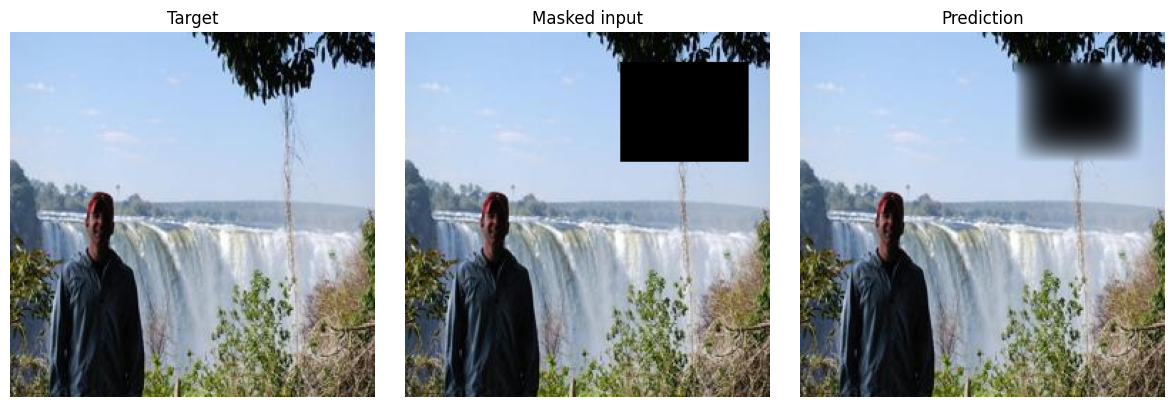

In [76]:
# Run the baseline on a single test sample and visualize
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
masked_img = x_in[:3].unsqueeze(0)          # (1,3,H,W)
mask_b     = mask.unsqueeze(0)              # (1,1,H,W)
pred_diffusion = diffusion_inpaint(masked_img, mask_b, num_iters=NUM_DIFFUSION_ITERS)

fig, ax = show_img_grid(
    tensors=[img, x_in[:3], pred_diffusion.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"]
)
fig.savefig(img_dir / "standard_diffusion.png", dpi=150, bbox_inches="tight")
plt.show()

## Baseline 2: Known-Neighbors-Only ("Wavefront")

This method imposes a strict constraint on the averaging process. A missing pixel is updated only if it is adjacent to at least one "known" pixel (either from the original image or a previously filled region). The new value is calculated as the average of these valid neighbors exclusively, ignoring any neighbors that are still empty.

This creates a "wavefront" effect where the hole fills layer-by-layer from the boundary inward. It prevents the initial black values (zeros) from contaminating the result. This approach generally yields sharper results and converges faster than standard diffusion because it relies purely on valid data.

In [29]:
@torch.no_grad()
def inpaint_known_neighbors_only(
    masked: torch.Tensor,  # (B,C,H,W) missing pixels can be 0
    mask: torch.Tensor,    # (B,1,H,W) 1=known, 0=missing
    num_iters: int = 500,
    tol: float = 0.0,      # set >0 for early stopping (optional)
) -> torch.Tensor:
    """
    Fill missing pixels using ONLY neighbors that are currently known/filled.
    Vectorized "wavefront" inpainting: missing pixels fill from boundary inward.

    Returns:
      x_filled: (B,C,H,W)
    """
    
    B, C, H, W = masked.shape
    device, dtype = masked.device, masked.dtype

    # 4-neighbor kernel
    k = torch.tensor([[0., 1., 0.],
                      [1., 0., 1.],
                      [0., 1., 0.]], device=device, dtype=dtype).view(1,1,3,3)

    # per-channel grouped kernel
    kC = k.repeat(C, 1, 1, 1)  # (C,1,3,3)

    img_inpainted = masked.clone()
    K = mask.clone()  # (B,1,H,W) current knownness (starts with original known pixels)

    for _ in range(num_iters):
        img_inpainted_prev = img_inpainted

        # Sum ONLY from currently known pixels:
        # (x*K) broadcasts K across channels => (B,C,H,W)
        neigh_sum = F.conv2d(img_inpainted * K, kC, padding=1, groups=C)      # (B,C,H,W)
        neigh_cnt = F.conv2d(K, k, padding=1)                     # (B,1,H,W), counts known neighbors

        # Pixels we are allowed to fill this iteration:
        fillable = (K == 0) & (neigh_cnt > 0)                     # (B,1,H,W)

        # Compute average of known neighbors (avoid division by 0 via masking)
        neigh_avg = neigh_sum / (neigh_cnt + 1e-8)                # (B,C,H,W) via broadcast

        # Update ONLY fillable pixels (broadcast fillable to channels)
        fillableC = fillable.expand(-1, C, -1, -1)                # (B,C,H,W)
        img_inpainted = torch.where(fillableC, neigh_avg, img_inpainted)

        # Mark newly filled pixels as known for next iteration
        K = torch.where(fillable, torch.ones_like(K), K)

        # stop if everything filled
        if (K == 0).sum().item() == 0:
            break

        # optional early stop based on small changes
        if tol > 0.0:
            diff = (img_inpainted - img_inpainted_prev).abs()
            # consider only pixels that were updated this iter
            change = diff * fillableC
            if change.max().item() < tol:
                break

    return img_inpainted


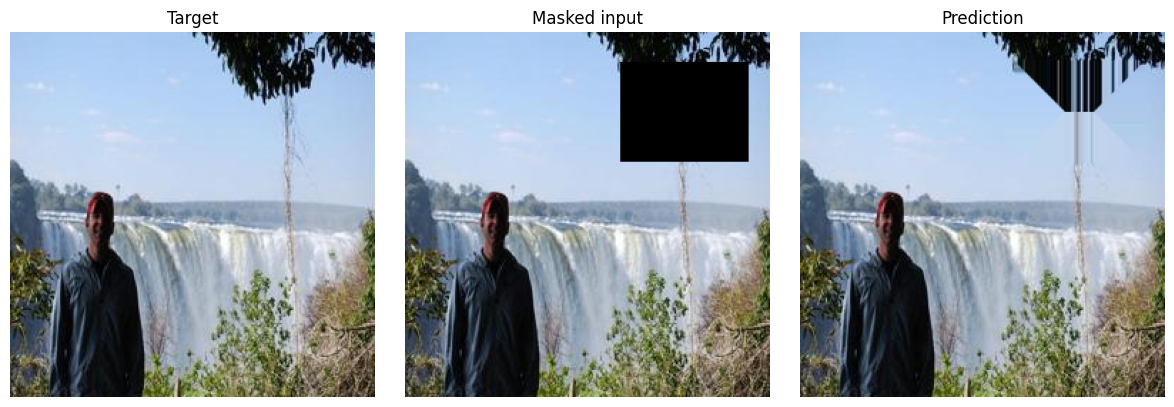

In [77]:
# Run the baseline on a single test sample and visualize
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
masked_img = x_in[:3].unsqueeze(0)          # (1,3,H,W)
mask_b     = mask.unsqueeze(0)              # (1,1,H,W) channel with mask

pred_only_neigh = inpaint_known_neighbors_only(masked_img, mask_b, num_iters=NUM_DIFFUSION_ITERS)

fig, ax = show_img_grid(
    tensors=[img, x_in[:3], pred_only_neigh.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"]
)
fig.savefig(img_dir / "wavefront.png", dpi=150, bbox_inches="tight")
plt.show()

## Baseline 3: Weighted Diffusion

This is a hybrid approach of Baseline 1 and 2. It calculates the average of all four neighbors but assigns a higher importance (weight) to known pixels and a lower weight to missing ones.

Standard diffusion (Baseline 1) can be too slow and blurry, while "Known-Only" (Baseline 2) can sometimes produce hard, jagged artifacts where different "waves" meet. 

Weighting the known pixels higher prioritizes valid information while still allowing a small amount of smoothing from the undefined region, offering a compromise between the two extremes.


In [31]:
@torch.no_grad()
def diffusion_inpaint_weighted_knownness(
    masked: torch.Tensor,  # (B,C,H,W)
    mask: torch.Tensor,    # (B,1,H,W) 1=known, 0=missing
    num_iters: int = 400,
    alpha: float = 1.0,    # weight for missing neighbors (0 -> known-only; 1 -> standard diffusion)
) -> torch.Tensor:
    """
    Weighted diffusion inpainting:
    neighbors are averaged with weights depending on knownness:
    w = 1 for known pixels, w = alpha for missing pixels.

    alpha=1.0 -> standard diffusion
    alpha=0.0 -> known-neighbors-only averaging (but without wavefront logic)
    """
    assert masked.dim() == 4
    assert mask.dim() == 4 and mask.size(1) == 1
    B, C, H, W = masked.shape
    device, dtype = masked.device, masked.dtype

    k = torch.tensor([[0., 1., 0.],
                      [1., 0., 1.],
                      [0., 1., 0.]], device=device, dtype=dtype).view(1,1,3,3)
    kC = k.repeat(C, 1, 1, 1)

    known = mask
    missing = 1.0 - known

    # weights per pixel (known=1, missing=alpha)
    Wpix = known + alpha * missing   # (B,1,H,W)

    img_inpainted = masked.clone()

    for _ in range(num_iters):
        # weighted neighbor sum
        neigh_sum = F.conv2d(img_inpainted * Wpix, kC, padding=1, groups=C)   # (B,C,H,W)
        # weighted neighbor count
        neigh_wsum = F.conv2d(Wpix, k, padding=1)                # (B,1,H,W)

        neigh_avg = neigh_sum / (neigh_wsum + 1e-8)

        # keep known pixels fixed, update missing pixels
        img_inpainted = img_inpainted * known + neigh_avg * missing

    return img_inpainted


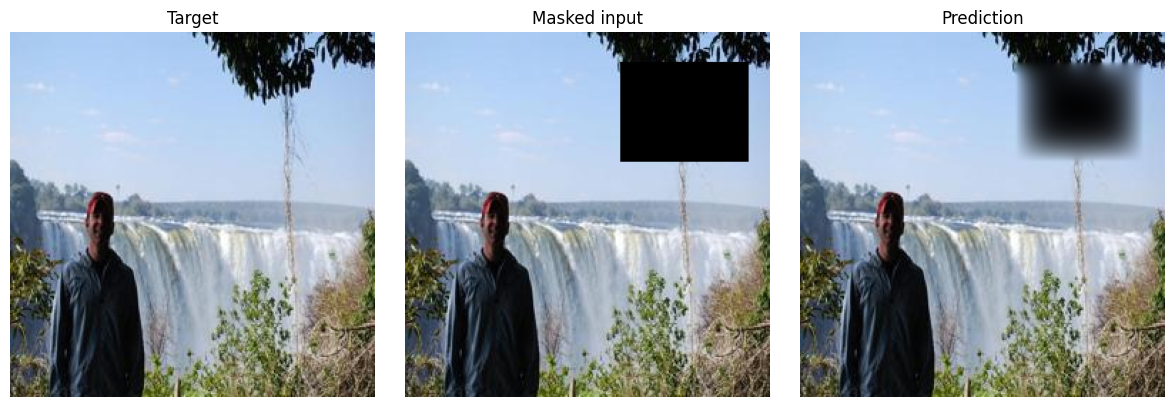

In [78]:
# Run the baseline on a single test sample and visualize
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
masked_img = x_in[:3].unsqueeze(0)
mask_b     = mask.unsqueeze(0)
pred_weigthed = diffusion_inpaint_weighted_knownness(masked_img, mask_b, num_iters=NUM_DIFFUSION_ITERS, alpha=0.5)

fig, ax = show_img_grid(
    tensors=[img, x_in[:3], pred_weigthed.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"]
)
fig.savefig(img_dir / "diffusion_weighted.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# Compute the reference metrics (MAE/PSNR) for the baseline
ALPHA = 0.5

def make_predictor(fn, **kwargs):
    def predictor(x_in, mask):
        return fn(x_in[:, :3], mask, num_iters=NUM_DIFFUSION_ITERS, **kwargs)   # x_in(B,3,H,W)
    return predictor

# Collect results for the final comparison table (models added later, in Evaluation).
results_table = []

baseline_methods = [
    ("Diffusion", make_predictor(diffusion_inpaint)),
    ("Wavefront", make_predictor(inpaint_known_neighbors_only)),
    ("Weighted",  make_predictor(diffusion_inpaint_weighted_knownness, alpha=ALPHA)),
]

for name, pred in baseline_methods:
    mae, psnr = evaluate_miss(test_loader, pred, device=DEVICE)
    results_table.append((name, mae, psnr))
    print(f"{name:12s}  MAE_miss: {mae:.4f}   PSNR_miss: {psnr:.2f} dB")

Diffusion     MAE_miss: 0.2479   PSNR_miss: 9.57 dB
Wavefront     MAE_miss: 0.1247   PSNR_miss: 13.94 dB
Weighted      MAE_miss: 0.2419   PSNR_miss: 9.71 dB


## Baseline Results

All three baselines are evaluated on the test set using the same `[0,1] evaluation protocol`. The metrics are computed only on the missing region.

| Baseline   | MAE_miss ↓ | PSNR_miss ↑ |
|------------|-----------:|------------:|
| Diffusion  | 0.248      | 9.57 dB     |
| Wavefront  | **0.125**  | **13.94 dB**|
| Weighted (α=0.5) | 0.242 | 9.71 dB     |

The **wavefront method performs clearly best**, reducing the MAE from 0.248 to 0.125 and improving PSNR by more than 4 dB compared with standard diffusion.

The main difference is how missing pixels are handled. Standard diffusion also averages over pixels inside the hole that are still zero. These zero values influence the reconstruction and lead to a darker and smoother result. The wavefront method only uses pixels that are already known or filled and therefore propagates information from the boundary toward the center without including the remaining zero values.

The **weighted diffusion method** reduces the influence of missing pixels using `α = 0.5`, but still includes them in the average. As a result, it performs only slightly better than standard diffusion.

Overall, even the best baseline (wavefront, PSNR ≈ 14 dB) is limited to propagating existing pixel values from the surrounding area and cannot reconstruct more complex texture or image structure. The learned models are therefore expected to improve on this baseline by using information learned from the training data.

# Models

This section defines the architectures of the two neural models: a **convolutional autoencoder** and a **U-Net**. Both take the 4-channel input (masked RGB + mask) and predict the reconstructed RGB image.

Both share the same encoder–decoder backbone: an encoder that downsamples to a bottleneck, a decoder that upsamples back. The only difference — the U-Net adds skip connections from encoder to decoder, while the autoencoder forces everything through the bottleneck. This isolates the effect of skip connections.

## A) Convolutional Autoencoder

In this section we start with a convolutional encoder–decoder autoencoder, introduced in the lecture, as a simple neural baseline for inpainting. Applying such an encoder–decoder to reconstruct a masked region follows the Context Encoder approach to inpainting [Pathak et al., 2016]. The double-convolution building block (two stacked 3×3 convolutions) is a common CNN design also used in U-Net [Ronneberger et al., 2015].

This architecture follows a classic Encoder-Bottleneck-Decoder structure. 
The Encoder progressively downsamples the input (MaxPool), compressing spatial information into a compact abstract representation (the bottleneck). This forces the model to learn high-level semantic features, such as shapes and textures—rather than merely memorizing pixel values.  

The Decoder then attempts to reconstruct the original image from this compressed state by upsampling step by step back to full resolution. The output is again a 3-channel RGB image.

The bottleneck forces the model to use spatial context (not just local interpolation), while the fully convolutional design preserves translation-equivariance and works naturally on images. 

In [34]:
class DoubleConvBlock(nn.Module):
    """Two 3×3 conv layers with BatchNorm+ReLU for local feature extraction and refinement."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            # bias=False is used because BatchNorm already includes a learnable bias term,
            # making a standard convolutional bias redundant.
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            #nn.GroupNorm(num_groups=num_groups, num_channels=out_ch),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            #nn.GroupNorm(num_groups=num_groups, num_channels=out_ch),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """
    Encoder step: extract features (DoubleConv), then downsample by 2 to compresses spatial dimensions.
    Structure: DoubleConv -> MaxPool which reduces the image size by half (H/2, W/2)
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConvBlock(in_ch, out_ch)  # learn richer features at this resolution
        self.pool = nn.MaxPool2d(2)                 # H,W -> H/2,W/2 

    def forward(self, x):
        x = self.conv(x)
        return self.pool(x)


class Up(nn.Module):
    """Decoder step: Restores spatial resolution (Upsample by 2) to reconstruct the image.
    Structure: Upsample -> Reduce Channels (1x1 Conv) -> DoubleConv
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")       # H,W -> 2H,2W
        self.reduce = nn.Conv2d(in_ch, out_ch, kernel_size=1)       # Reduce channel depth to match the next layer [B, in_ch, H, W] → [B, out_ch, H, W]
        self.conv = DoubleConvBlock(out_ch, out_ch)                 # refine details after upsampling
    
    def forward(self, x):
        x = self.up(x)
        x = self.reduce(x)
        return self.conv(x)


In [35]:
class InpaintAutoEncoder(nn.Module):               
    """
    Encoder–decoder baseline for inpainting (no skip connections). 
    Input: 4ch (RGB+mask), output: 3ch RGB.
    
    1. Encoder: Compress input into a low-res, high-level abstract representation (Bottleneck).
    2. Bottleneck: The network is forced to discard noise and rely on global context.
    3. Decoder: Reconstructs the full-resolution image from the latent features.
    """
    def __init__(self, in_ch=4, out_ch=3, base=64):
        super().__init__()
        # ---- Encoder: progressively downsample to build global context ---- 
        # 256 -> 128 -> 64 -> 32 -> 16
        self.e1 = Down(in_ch, base)         # 256 -> 128
        self.e2 = Down(base, base*2)    # 128 -> 64
        self.e3 = Down(base*2, base*4)  # 64 -> 32
        self.e4 = Down(base*4, base*8)  # 32 -> 16

        # bottleneck: highest-level representation (largest receptive field)
        # (16x16 resolution)
        self.bottleneck = DoubleConvBlock(base*8, base*16)   # 16 -> 16

        # ---- Decoder: upsample back to full resolution and refine ----
        # 16 -> 32 -> 64 -> 128 -> 256
        self.d4 = Up(base*16, base*8)   # 16 -> 32
        self.d3 = Up(base*8, base*4)    # 32 -> 64
        self.d2 = Up(base*4, base*2)    # 64 -> 128
        self.d1 = Up(base*2, base)      # 128 -> 256   

        # Output Head: Projects features back to RGB space (64 -> 3 channels)
        self.head = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x_in):
        # Downsample
        x = self.e1(x_in)           # [B,4,H,W]
        x = self.e2(x)
        x = self.e3(x)
        x = self.e4(x)

        # Contextual processing
        x = self.bottleneck(x)

        # Upsample
        x = self.d4(x)
        x = self.d3(x)
        x = self.d2(x)
        x = self.d1(x)

        out = self.head(x)         # [B,3,H,W] (prediction)
        return out

## B) U-Net with Skip Connections (Concat)

In this section we use a U-Net-style architecture, introduced in the lecture, as a stronger CNN baseline for inpainting. It adresses the bottleneck issue by adding Skip Connections between corresponding layers of the Encoder and Decoder.

The encoder still builds global context by downsampling, while the decoder upsamples back to full resolution. The skip connections pass high-resolution feature maps directly to the decoder, which helps preserve fine spatial details such as edges and textures that are often lost in a bottleneck-only model.

This makes U-Net particularly well-suited for inpainting: the bottleneck captures the overall scene layout, while the skip connections carry detailed information (like edges and textures) directly to the decoder. This helps the model fill the hole more sharply and keeps the boundary between known and reconstructed pixels more stable.

In [96]:
class DownWithSkip(nn.Module):
    """ 
    Encoder block that preserves spatial features before downsampling. 
    Returns the high-res feature map, sent across to decoder and the downsampled feature map.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.conv(x)
        x = self.pool(skip)
        return skip, x


class UpWithSkip(nn.Module):
    """
    Decoder block that fuses global context with local details.
    Upsample -> (optional pad) -> concat with skip -> DoubleConv
    """
    def __init__(self, in_ch, out_ch, skip_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.reduce = nn.Conv2d(in_ch, out_ch, kernel_size=1)       # [B, in_ch, H, W] → [B, out_ch, H, W]
        self.conv = DoubleConvBlock(out_ch + skip_ch, out_ch)       # After concat: out_ch + skip_ch channels
    
    def forward(self, x, skip):
        x = self.up(x)
        x = self.reduce(x)

        # handle odd size mismatches of inputs robustly by padding the upsampled feature to match size of the skip
        diffY = skip.size(2) - x.size(2)
        diffX = skip.size(3) - x.size(3)
        if diffY != 0 or diffX != 0:
            x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                          diffY // 2, diffY - diffY // 2])

        # Concatenate along channel dimension (dim=1)
        x = torch.cat([skip, x], dim=1)         # (B, C_up+C_skip, H, W)

        return self.conv(x)


In [37]:
class InpaintUNet(nn.Module):
    """
    U-Net with skip connections.
    Input:  (B,4,H,W) masked RGB + mask channel
    Output: (B,3,H,W) prediction
    """
    def __init__(self, in_ch=4, out_ch=3, base=64):
        super().__init__()
        # Encoder: Capture context AND save details (skips)
        self.e1 = DownWithSkip(in_ch, base)         # 256 -> 128
        self.e2 = DownWithSkip(base, base*2)    # 128 -> 64
        self.e3 = DownWithSkip(base*2, base*4)  # 64 -> 32
        self.e4 = DownWithSkip(base*4, base*8)  # 32 -> 16

        # Bottleneck: Deepest semantic representation
        self.bottleneck = DoubleConvBlock(base*8, base*16)   # 16 -> 16

        self.d4 = UpWithSkip(base*16, base*8, base*8)   # 16 -> 32
        self.d3 = UpWithSkip(base*8, base*4, base*4)    # 32 -> 64
        self.d2 = UpWithSkip(base*4, base*2, base*2)    # 64 -> 128
        self.d1 = UpWithSkip(base*2, base, base)      # 128 -> 256

        self.head = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x_in):
        # Downsample path (Saving s1, s2, s3, s4)
        s1, x = self.e1(x_in)           # [B,4,H,W]
        s2, x = self.e2(x)
        s3, x = self.e3(x)
        s4, x = self.e4(x)

        x = self.bottleneck(x)

        # Upsample path (Injecting s4, s3, s2, s1)
        x = self.d4(x, s4)
        x = self.d3(x, s3)
        x = self.d2(x, s2)
        x = self.d1(x, s1)

        out = self.head(x)  # [B,3,H,W] (predictions)
        return out

# Training

This section covers how both models are trained, tuned, and produced. The training pipeline is shared, so both models are fit under identical conditions and any difference in results is due to architecture rather than the training procedure.

We first define the training setup — the loss, the epoch loop, and the experiment wrapper. We then tune each model's hyperparameters on the validation set, and finally train both models with their chosen configuration to obtain the models used in the evaluation.

## Training Setup

This section defines the shared training pipeline used for both models, so they are fit and selected under identical conditions

`train_model` runs the epoch loop, optimizing the
masked MAE and validating with the evaluation protocol after each epoch. 

`run_experiment` wraps it with fixed seeds and hyperparameters for reproducible, comparable runs, and

`get_model` loads a cached checkpoint if available or otherwise triggers training.

In [95]:
def train_loss_miss(model, batch, device):
    """
    The loss is the Masked MAE computed in [0,1] pixel space, 
    over the missing region only.
    """
    eps = 1e-8                  # numerical stability for division
    x_in, y, mask = batch       # x_in: (B,4,H,W), y: (B,3,H,W), mask: (B,1,H,W)
    x_in, y, mask = x_in.to(device), y.to(device), mask.to(device)

    y_hat = model(x_in)         # predict reconstructed RGB in the same space as y

    missing = 1.0 - mask

    # ---- TRAIN LOSS (MAE) ----
    abs_err = (y_hat - y).abs() * missing       # absolute reconstruction error, but only counted on missing pixels

    # mean over missing pixels and channels
    denom = missing.sum() * y.shape[1]      # calculates mean absolute error over all missing pixels, 
                                            # aggregated across the entire batch and all channels.
    loss = abs_err.sum() / (denom + eps)

    return loss         


In [39]:
def train_model(
    model, optimizer,
    train_dataloader, val_dataloader,
    epochs, model_save_path,
    log_to_wandb=False,
    device=None,
):
    """
    Train an inpainting model and validate using MAE/PSNR on the missing region (dataset-aggregated).
    """
    train_losses, val_maes, val_psnrs, epoch_times = [], [], [], []
    best_val_mae = float("inf")

    for epoch in range(epochs):
        start_time = time.time()
        print(f"[Inpainting] Epoch {epoch+1}/{epochs}")

        # ----- TRAIN -----
        model.train()
        train_loss_epoch = 0.0

        for step, batch in enumerate(tqdm(train_dataloader)):
            optimizer.zero_grad(set_to_none=True)               # set_to_none=True is a slight memory optimization over writing zeros
            loss = train_loss_miss(model, batch, device)
            loss.backward()
            optimizer.step()
            train_loss_epoch += loss.item()

        # Average the batch losses for reporting
        train_loss_epoch /= (step + 1)
        train_losses.append(train_loss_epoch)
        print(f"train loss (batch avg mae): {train_loss_epoch:.4f}")

        # ----- VALID (dataset-aggregated metrics (global)) -----
        eps = 1e-8
        max_val = 1.0

        model.eval()
        total_abs, total_sq, total_denom = 0.0, 0.0, 0.0

        with torch.no_grad():
            for step, batch in enumerate(tqdm(val_dataloader, leave=False)):
                # Return raw error sums (numerator) and pixel counts (denominator).
                # Aggregate over all batches and average over whole dataset (not per-batch averages)
                abs_num, sq_num, denom = eval_sums_miss(model_predictor(model), batch, device)
                total_abs += abs_num
                total_sq += sq_num
                total_denom += denom              # pixels × channels

            # Compute final metrics over the entire validation dataset to prevent
            #  small batches or images with small masks from skewing results
            val_mae = total_abs / (total_denom + eps)
            val_mse = total_sq / (total_denom + eps)
            val_psnr = 10.0 * math.log10((max_val ** 2) / (val_mse + eps))    # max_val: MAX pixel value (1.0 if images in [0,1])
    
        val_maes.append(val_mae)
        val_psnrs.append(val_psnr)

        print(f"val MAE_miss (pixel-weighted):  {val_mae:.4f}")
        print(f"val PSNR_miss:                 {val_psnr:.2f} dB")

        # Save model if metric improves (Best MAE)
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), model_save_path)
            print(f"  → New best saved (val MAE_miss {best_val_mae:.4f})")

       # Logging
        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)                              # raw seconds
        epoch_time_formatted = format_time(epoch_time)              # human-readable string for logging

        if log_to_wandb:
            wandb.log({
                "model": model.__class__.__name__,
                "epoch": epoch + 1,
                "train_loss": train_loss_epoch,
                "val_mae": val_mae,
                "val_psnr": val_psnr,
                "epoch_time": epoch_time_formatted,
                "lr": optimizer.param_groups[0]["lr"]
            })


    return {
        "train_loss": train_losses,
        "val_mae": val_maes,
        "val_psnr": val_psnrs,
        "epoch_times": epoch_times,
        "best_val_mae": float(best_val_mae),
        "num_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }

In [40]:
def run_experiment(ModelCls, hyper_params, name, num_samples, 
                   train_loader, val_loader):
    """
    Set seeds, build model+optimizer from hyperparameters, run training, and return results 
    plus artifacts.
    """
    
    set_seeds(SEED)

    # Dynamic hyperparameter configuration:
    base = hyper_params["base"]
    lr = hyper_params["lr"]
    epochs = hyper_params["epochs"]

    # Dynamic model instantiation
    model = ModelCls(base=base).to(DEVICE)
    model_save_path = CHECKPOINTS_DIR / f"inpaint_{name}.pt"

    # Number of trainable parameters (for the comparison table)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    init_wandb(
        model=model,
        opt_name = opt.__class__.__name__,
        name=name,
        num_params=num_params,
        sample_number=num_samples
    )

    results = train_model(
      model=model,
      optimizer=opt,
      train_dataloader=train_loader,
      val_dataloader=val_loader,
      epochs=epochs,
      model_save_path=model_save_path,
      #log_to_wandb=True,
      device=DEVICE
    )

    return results, model, opt

In [41]:
def load_model(model, model_path, device=DEVICE):
    """Load checkpoint weights, freeze parameters, and switch to eval mode."""
    # Load serialized weights;
    state_dict = torch.load(model_path, weights_only=True, map_location=device)     # map_location ensures compatibility if moving between CPU/GPU
    model.load_state_dict(state_dict, strict=True)      # Enforce exact structural match between the architecture and the saved weights

    # Freeze all parameters
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    return model

In [42]:
def get_model(ModelCls, hyper_params, dir=CODE_ROOT, name="autoencoder", train_loader=train_loader, val_loader=val_loader):
    """
    Load existing checkpoint+results if available; otherwise train, save, and return the 
    best frozen model.
    """
    
    model_path = CHECKPOINTS_DIR / f"inpaint_{name}.pt"
    results_path = dir / f"outputs/results_{name}.json"

    # Check for existing artifacts (Lazy Loading)
    if model_path.exists() and results_path.exists():

        with open(results_path, "r") as f:
            results = json.load(f)

    else:
        # Trigger full training pipeline
        results, model, opt = run_experiment(ModelCls, hyper_params, num_samples=NUM_SAMPLES, name=name, 
                                             train_loader=train_loader, val_loader=val_loader)
        cleanup(model, opt)     # Free up GPU memory immediately after training which prevents OOM errors
        wandb.finish()

        # Persist computed metrics to disk
        out_dir = WORK_ROOT / "outputs"
        out_dir.mkdir(exist_ok=True)

        with open(out_dir / f"results_{name}.json", "w") as f:
            json.dump(results, f, indent=2)

    # Re-instantiate a clean model architecture and load the best weights (Frozen state)
    print("Load model...")
    base = hyper_params["base"]
    model = ModelCls(base=base).to(DEVICE)
    model = load_model(model, model_path)

    return results, model

In [43]:
@torch.no_grad()
def predict_one(model, x_in, target_norm, mask, device):
    """Predict one inpainted image and paste the prediction only into the missing region."""
    x_in_b = x_in.unsqueeze(0).to(device)   # (1,4,H,W)
    y_hat_norm = model(x_in_b).squeeze(0).cpu()  # (3,H,W)
    final_norm = (target_norm * mask) + (y_hat_norm * (1 - mask))

    return final_norm

## Hyperparameter Tuning

Each model is tuned on the validation set before the final comparison. We run a small grid search: every configuration is trained, and the one with the lowest validation MAE is selected. Model selection uses only the validation split — the test set is untouched
until the final evaluation.

The two models are tuned independently, so each is compared at its own best configuration. Given the compute budget, we search a small grid on a single validation
split rather than using k-fold cross-validation; with a fixed held-out validation set of sufficient size this is an adequate and far cheaper protocol. In practice we tune the learning rate, which has the largest effect on training; the grid is written to also cover model capacity (`base`), which can be enabled if more compute is available.

In [44]:
# Define Hyperparameter grid
LR_GRID   = [1e-3, 1e-4]
BASE_GRID = [32, 64]

param_grid = [
    {"lr": lr, "base": base, "epochs": TUNE_EPOCHS}
    for lr in LR_GRID
    for base in BASE_GRID
]

In [45]:
def tune_hyperparams(ModelCls, param_grid, name, train_loader, val_loader):
    """
    Train one run per config, select the config with the lowest validation MAE.
    Returns the best config plus a record of all runs for reporting.
    """
    results_log = []
    best = None

    for i, hp in enumerate(param_grid):
        run_name = f"{name}_tune_{i}"
        print(f"\n[tuning] {name} | config {i+1}/{len(param_grid)}: {hp}")

        results, model, opt = run_experiment(
            ModelCls, hp, name=run_name, num_samples=NUM_SAMPLES,
            train_loader=train_loader, val_loader=val_loader
        )
        cleanup(model, opt)
        wandb.finish()

        val_mae = results["best_val_mae"]
        results_log.append({"config": hp, "val_mae": val_mae, "curve": results["val_mae"], })

        if best is None or val_mae < best["val_mae"]:
            best = {"config": hp, "val_mae": val_mae}

    print(f"\n[tuning] {name} best: {best['config']} (val MAE {best['val_mae']:.4f})")
    return best, results_log

In [98]:
def get_best_config(ModelCls, param_grid, name, train_loader, val_loader,
                    dir=WORK_ROOT):
    """Load the tuned config if it exists; otherwise run the search, save config + tuning log, and return it."""
    
    cfg_path = dir / "outputs" / f"best_config_{name}.json"
    log_path = dir / "outputs" / f"tuning_log_{name}.json"

    if cfg_path.exists():
        with open(cfg_path, "r") as f:
            best_config = json.load(f)
        print(f"[tuning] loaded cached config for {name}: {best_config}")
    else:
        best, results_log = tune_hyperparams(ModelCls, param_grid, name, train_loader, val_loader)
        best_config = best["config"]

        cfg_path.parent.mkdir(exist_ok=True, parents=True)
        with open(cfg_path, "w") as f:
            json.dump(best_config, f, indent=2)
        with open(log_path, "w") as f:
            json.dump(results_log, f, indent=2)
        print(f"[tuning] saved config for {name}: {best_config}")

    return best_config

## Run

Using the best configuration found for each model, we now train the final autoencoder and U-Net. These are the models used in the evaluation and significance testing that follow. `get_model` loads an existing checkpoint if one is available and otherwise runs the full training pipeline.

### Autoencoder

In [47]:
# Get tuned config
ae_config = get_best_config(InpaintAutoEncoder, param_grid, "autoencoder",
                            train_loader, val_loader)
ae_config = {**ae_config, "epochs": FINAL_EPOCHS}    # override for the full run

# Run experiment
results_autoencoder, best_autoencoder = get_model(
    ModelCls=InpaintAutoEncoder, hyper_params=ae_config,
    dir=CODE_ROOT, name="autoencoder",
    train_loader=train_loader, val_loader=val_loader
)


[tuning] autoencoder | config 1/4: {'lr': 0.001, 'base': 32, 'epochs': 15}
Seeds set to 51


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: michele-marschner (michele-marschner-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Path /kaggle/input/datasets/mmarschn/inpainting wasn't read/writable
wandb: WARNING Falling back to temporary directory /tmp.


[Inpainting] Epoch 1/15


100%|██████████| 132/132 [01:55<00:00,  1.14it/s]


train loss (batch avg mae): 0.1956


...

val MAE_miss (pixel-weighted):  0.1195
val PSNR_miss:                 15.02 dB
[Inpainting] Epoch 30/30


100%|██████████| 132/132 [03:38<00:00,  1.66s/it]


train loss (batch avg mae): 0.0832


val MAE_miss (pixel-weighted):  0.1196
val PSNR_miss:                 14.87 dB


Load model...


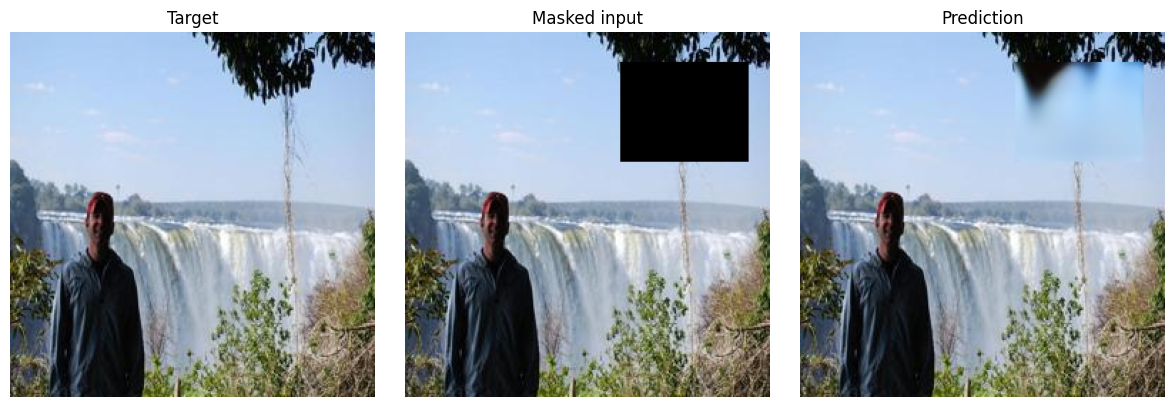

In [79]:
# Qualitative sanity check: Visually inspect the model output on a held-out test sample 
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
pred_autoencoder = predict_one(best_autoencoder, x_in, img, mask, device=DEVICE)

fig, ax = show_img_grid(
    tensors=[img, x_in, pred_autoencoder.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"],
)
fig.savefig(img_dir / f"autoencoder_result.png", dpi=150, bbox_inches="tight")
plt.show()

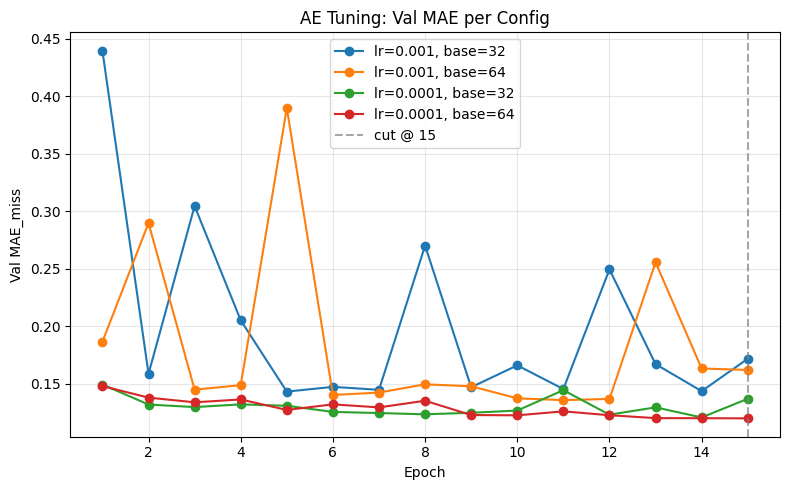

In [80]:
with open(WORK_ROOT / "outputs" / "tuning_log_autoencoder.json") as f:
    log_ae = json.load(f)

fig, ax = plot_tuning_curves(log_ae, title="AE Tuning: Val MAE per Config", cut=TUNE_EPOCHS)
fig.savefig(img_dir / f"tuning_curves_ae.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
# Free up GPU memory immediately after training to avoid OOM error
cleanup(best_autoencoder)

### U-Net

In [51]:
# Get tuned config
unet_config = get_best_config(InpaintUNet, param_grid, "unet",
                              train_loader, val_loader)
unet_config = {**unet_config, "epochs": FINAL_EPOCHS}    # override for the full run

# Run experiment
results_unet, best_unet = get_model(
    ModelCls=InpaintUNet, hyper_params=unet_config,
    dir=CODE_ROOT, name="unet",
    train_loader=train_loader, val_loader=val_loader
)


[tuning] unet | config 1/4: {'lr': 0.001, 'base': 32, 'epochs': 15}
Seeds set to 51


[Inpainting] Epoch 1/15


100%|██████████| 132/132 [01:46<00:00,  1.24it/s]


train loss (batch avg mae): 0.1760


val MAE_miss (pixel-weighted):  0.3556
val PSNR_miss:                 7.39 dB
  → New best saved (val MAE_miss 0.3556)
[Inpainting] Epoch 2/15


...

val MAE_miss (pixel-weighted):  0.1142
val PSNR_miss:                 15.27 dB
[Inpainting] Epoch 30/30


100%|██████████| 132/132 [04:32<00:00,  2.06s/it]


train loss (batch avg mae): 0.0777


val MAE_miss (pixel-weighted):  0.1145
val PSNR_miss:                 15.36 dB


Load model...


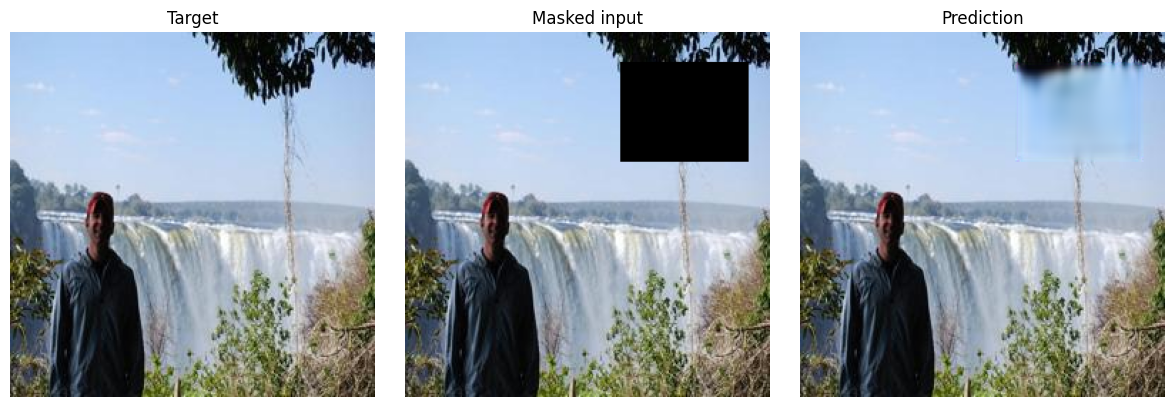

In [81]:
# Qualitative sanity check: Visually inspect the model output on a held-out test sample 
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
pred_unet = predict_one(best_unet, x_in, img, mask, device=DEVICE)

fig, ax = show_img_grid(
    tensors=[img, x_in, pred_unet.squeeze(0)],
    titles=["Target", "Masked input", "Prediction"],
)
fig.savefig(img_dir / f"unet_result.png", dpi=150, bbox_inches="tight")
plt.show()

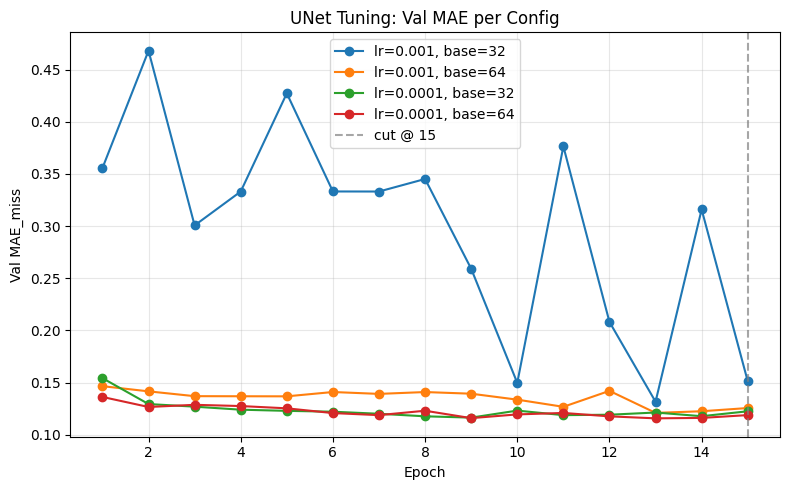

In [82]:
import json
with open(WORK_ROOT / "outputs" / "tuning_log_unet.json") as f:
    log_unet = json.load(f)

fig, ax = plot_tuning_curves(log_unet, title="UNet Tuning: Val MAE per Config", cut=TUNE_EPOCHS)
fig.savefig(img_dir / f"tuning_curves_unet.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
# Free up GPU memory immediately after training to avoid OOM error
cleanup(best_unet)

# Evaluation

This section compares all methods — the three diffusion-based baselines, the autoencoder, and the
U-Net — under the shared evaluation protocol defined earlier. All results are reported on
the test set, on the missing region only, so every approach is scored the same way.

We first compare the methods quantitatively using MAE and PSNR. We then test whether the
difference between the two neural models is statistically significant, rather than an
artifact of the particular test set. Finally, we inspect the reconstructions and their
error maps qualitatively to see where each model succeeds and fails.

In [55]:
@torch.no_grad()
def per_image_mae(dataset, predictor_fn, device, eps=1e-8):
    """Return a list of masked MAE values, one per image in the dataset.
    Used for the paired significance test (and error-map selection)."""
    maes = []
    for i in range(len(dataset)):
        x_in, y, mask = dataset[i]
        x_in = x_in.unsqueeze(0).to(device)
        y    = y.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        y_hat = predictor_fn(x_in, mask).clamp(0, 1)
        y     = y.clamp(0, 1)

        missing = 1.0 - mask
        abs_err = ((y_hat - y).abs() * missing).sum()
        denom   = missing.sum() * y.shape[1]
        maes.append((abs_err / (denom + eps)).item())

    return maes

In [56]:
mae_ae   = per_image_mae(test_data, model_predictor(best_autoencoder), device=DEVICE)
mae_unet = per_image_mae(test_data, model_predictor(best_unet),  device=DEVICE)

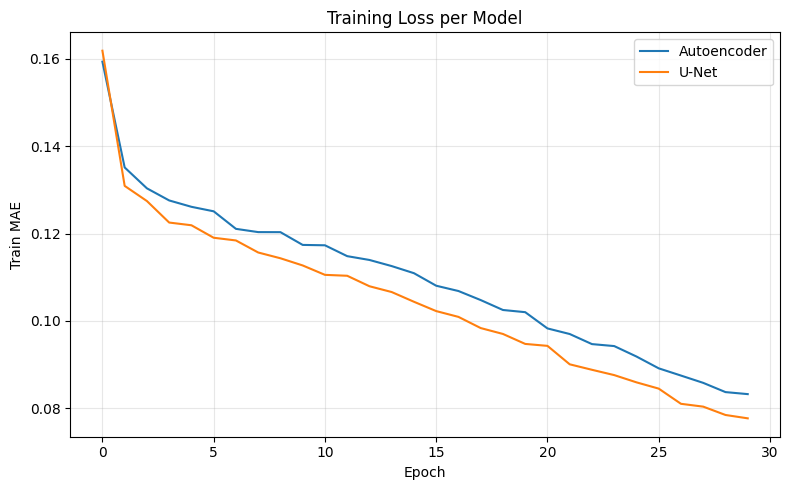

In [83]:
fig, ax = plot_losses({
    "Autoencoder": results_autoencoder["train_loss"],
    "U-Net":       results_unet["train_loss"],
}, title="Training Loss per Model", ylabel="Train MAE")

fig.savefig(img_dir / f"training_losses.png", dpi=150, bbox_inches="tight")
plt.show()

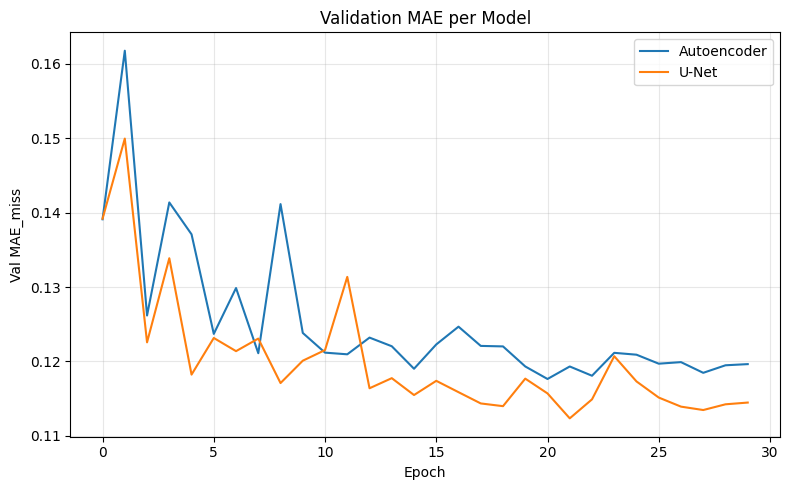

In [84]:
fig, ax = plot_losses({
    "Autoencoder": results_autoencoder["val_mae"],
    "U-Net":       results_unet["val_mae"],
}, title="Validation MAE per Model", ylabel="Val MAE_miss")

fig.savefig(img_dir / f"val_losses.png", dpi=150, bbox_inches="tight")
plt.show()

## Quantitative Comparison

In [59]:
ae_mae,   ae_psnr   = evaluate_miss(test_loader, model_predictor(best_autoencoder), device=DEVICE)
unet_mae, unet_psnr = evaluate_miss(test_loader, model_predictor(best_unet),  device=DEVICE)

In [60]:
model_methods = [
    ("Autoencoder", model_predictor(best_autoencoder)),
    ("U-Net",       model_predictor(best_unet)),
]

for name, pred in model_methods:
    mae, psnr = evaluate_miss(test_loader, pred, device=DEVICE)
    results_table.append((name, mae, psnr))

# Print the complete comparison
print(f"{'Method':12s}  {'MAE_miss':>9s}  {'PSNR_miss':>9s}")
for name, mae, psnr in results_table:
    print(f"{name:12s}  {mae:9.4f}  {psnr:7.2f} dB")

Method         MAE_miss  PSNR_miss
Diffusion        0.2479     9.57 dB
Wavefront        0.1247    13.94 dB
Weighted         0.2419     9.71 dB
Autoencoder      0.1145    15.32 dB
U-Net            0.1101    15.53 dB


### Quantitative Results

The quantitative results confirm that the learned approaches outperform the interpolation-based baselines. Compared with the best baseline, the best learned model reduces the masked MAE by approximately **0.015**.

The difference between the autoencoder and U-Net is considerably smaller, with an MAE improvement of approximately **0.005**. 

## Statistical Significance

The U-Net achieves a lower MAE than the autoencoder, but a difference on a single test set could arise by chance. Since both models are evaluated on the *same* 600 images, the per-image scores are **paired**, and we analyse the per-image difference $\delta_i = \mathrm{MAE}_{\text{AE}}(i) - \mathrm{MAE}_{\text{U-Net}}(i)$.

We apply a **paired t-test** (compares mean difference, more powerful) and a **sign test** (only uses which model wins per image, fewer assumptions). The null hypothesis is that both models perform equally well; agreement between the two tests makes the conclusion robust.


In [85]:
delta = np.array(mae_ae) - np.array(mae_unet)   # positive => U-Net better

# Paired t-test
t_stat, p_ttest = stats.ttest_rel(mae_ae, mae_unet)

# Sign test (drop ties)
wins_unet = int(np.sum(delta > 0))
wins_ae   = int(np.sum(delta < 0))
n_eff     = wins_unet + wins_ae
p_sign = stats.binomtest(wins_unet, n_eff, 0.5, alternative="two-sided").pvalue

print(f"n = {len(delta)}  (U-Net better: {wins_unet}, AE better: {wins_ae})")
print(f"mean delta (AE - U-Net) = {delta.mean():.4f}")
print(f"paired t-test:  t = {t_stat:.3f},  p = {p_ttest:.4g}")
print(f"sign test:      p = {p_sign:.4g}")

n = 600  (U-Net better: 401, AE better: 199)
mean delta (AE - U-Net) = 0.0044
paired t-test:  t = 8.053,  p = 4.374e-15
sign test:      p = 1.185e-16


### Significance Test Results

The U-Net achieved a lower error on **401 of the 600 images**, and both statistical tests rejected the null hypothesis of no difference at a significance level of `α = 0.05`.

Thus, although the absolute improvement is relatively small, it is consistent across the test set and statistically significant.


## Qualitative Comparison

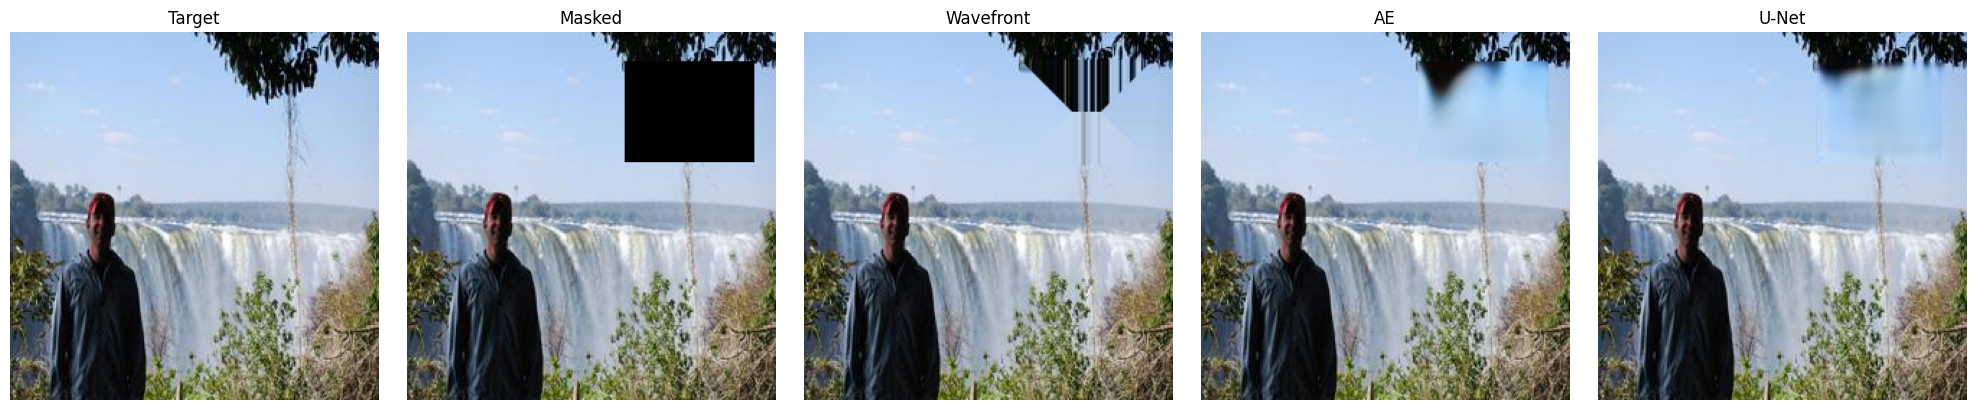

In [86]:
x_in, img, mask = test_data[TEST_SAMPLE_IDX]
wave = inpaint_known_neighbors_only(
    x_in[:3].unsqueeze(0), mask.unsqueeze(0), num_iters=NUM_DIFFUSION_ITERS
).squeeze(0)
ae   = predict_one(best_autoencoder,   x_in, img, mask, DEVICE)
unet = predict_one(best_unet, x_in, img, mask, DEVICE)

fig, _ = show_img_grid(
    tensors=[img, x_in, wave, ae, unet],
    titles=["Target", "Masked", "Wavefront", "AE", "U-Net"],
    cols=5,
)
fig.savefig(img_dir / f"qualitative_row.png", dpi=150, bbox_inches="tight")
plt.show()

### Qualitative Reconstruction Results

The wavefront method was the strongest of the diffusion-based baselines. Its reconstruction mainly propagates surrounding colours into the missing region, but it does not recover meaningful texture or scene structure.

The learned models produce visually more plausible reconstructions. The difference between the autoencoder and U-Net is much smaller: the U-Net appears slightly sharper in some regions, but the distinction is difficult to assess reliably from the reconstructed images alone. Both models still produce noticeably smoother textures than the original images.

In [87]:
@torch.no_grad()
def error_map(model, x_in, target, mask, device):
    """Absolute error over the missing pixels (mask) only, averaged across RGB -> (H,W)."""
    x_in_b = x_in.unsqueeze(0).to(device)
    y_hat  = model(x_in_b).squeeze(0).cpu().clamp(0, 1)
    err = (y_hat - target.clamp(0, 1)).abs().mean(dim=0)   # (H,W)
    missing = (1.0 - mask).squeeze(0)                      # (H,W), 1 in hole
    return err * missing                                   # zero outside hole

In [ ]:
def show_error_comparison(indices, dataset, ae_model, unet_model, device):
    """One row per index. Error maps share one color scale per row so brightness is comparable."""
    n = len(indices)
    fig, axes = plt.subplots(n, 6, figsize=(18, 3 * n))
    if n == 1:
        axes = axes[None, :]   # keep 2D indexing for a single row

    col_titles = ["Target", "Masked", "AE pred", "AE error", "U-Net pred", "U-Net error"]

    for r, idx in enumerate(indices):
        x_in, img, mask = dataset[idx]

        ae_pred   = predict_one(ae_model,   x_in, img, mask, device)
        unet_pred = predict_one(unet_model, x_in, img, mask, device)
        ae_err    = error_map(ae_model,   x_in, img, mask, device)
        unet_err  = error_map(unet_model, x_in, img, mask, device)
        vmax = max(ae_err.max().item(), unet_err.max().item())

        panels = [
            (img.permute(1,2,0),       None),
            (x_in[:3].permute(1,2,0),  None),
            (ae_pred.permute(1,2,0),   None),
            (ae_err,                   "hot"),
            (unet_pred.permute(1,2,0), None),
            (unet_err,                 "hot"),
        ]
        for c, (data, cmap) in enumerate(panels):
            ax = axes[r, c]
            if cmap:
                ax.imshow(data, cmap=cmap, vmin=0, vmax=vmax)
            else:
                ax.imshow(data.clamp(0, 1))
            if r == 0:
                ax.set_title(col_titles[c])
            ax.axis("off")

    plt.tight_layout()
    return fig

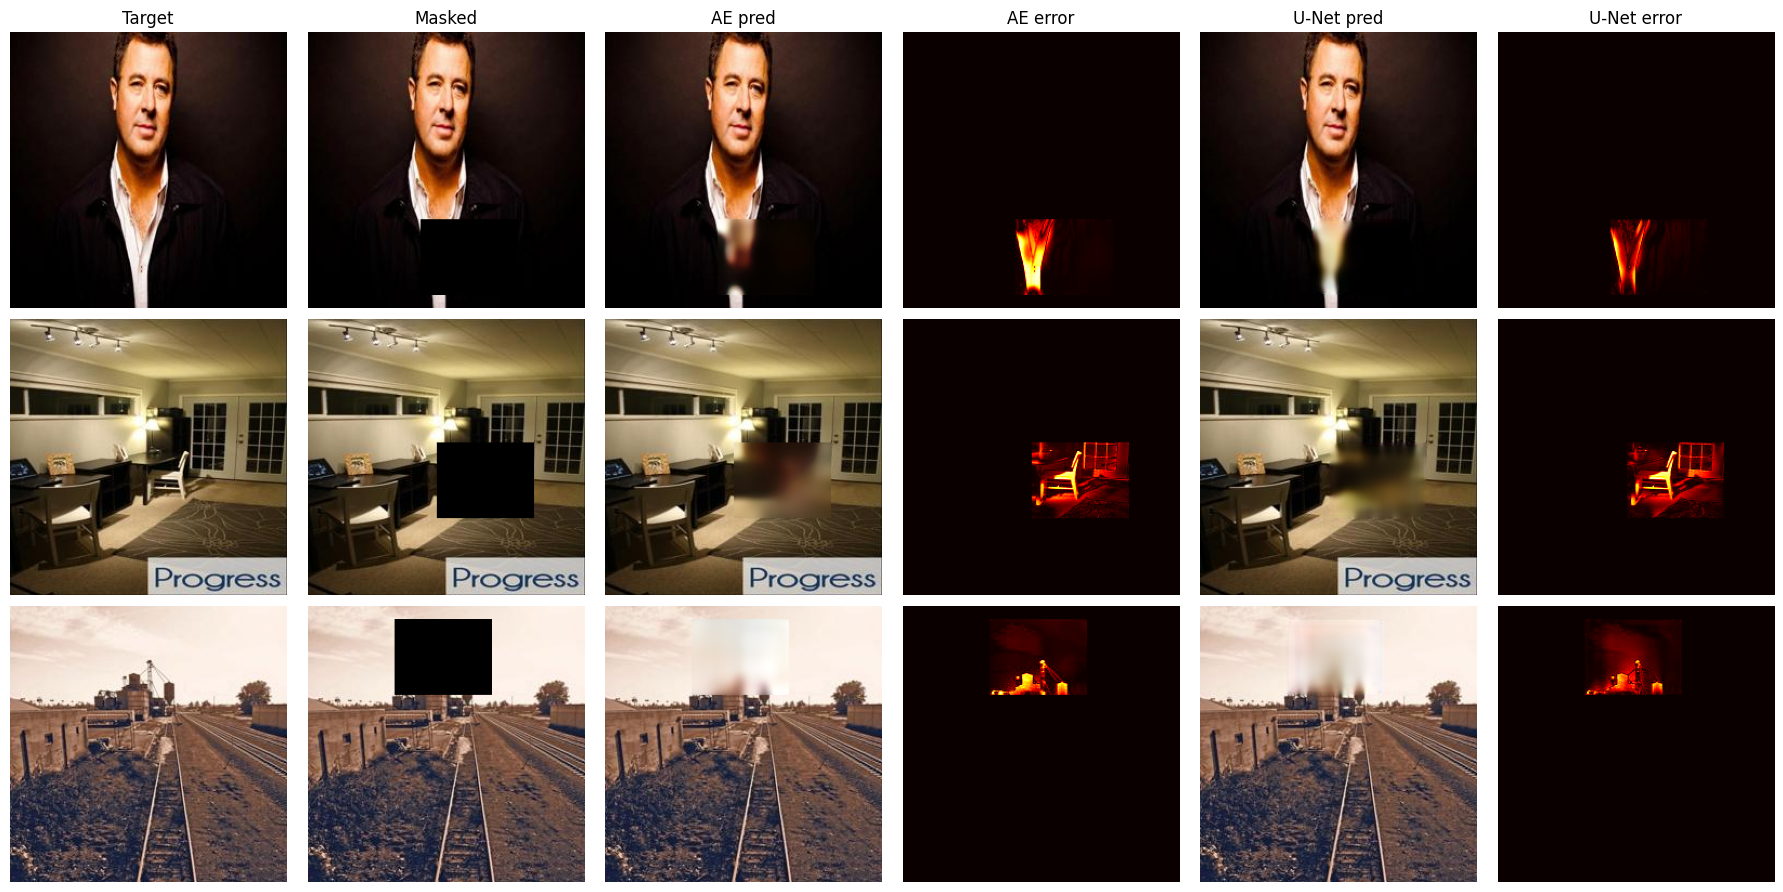

In [92]:
delta = np.array(mae_ae) - np.array(mae_unet)   # positive => U-Net better

idx_unet_wins = int(np.argmax(delta))                          # U-Net clearly better
idx_typical   = int(np.argmin(np.abs(delta - np.median(delta))))  # representative
idx_close     = int(np.argmin(np.abs(delta)))                  # models nearly tied

fig = show_error_comparison([idx_unet_wins, idx_typical, idx_close],
                      test_data, best_autoencoder, best_unet, device=DEVICE)

fig.savefig(img_dir / f"error_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Error Map Results

To examine the differences between the two learned models more closely, masked error maps were computed. Pixels outside the missing region are shown in black because they are not included in the evaluation. Within the masked region, darker values indicate a reconstruction closer to the target, while brighter values correspond to larger errors.

The autoencoder tends to show errors distributed more broadly across the missing region. For the U-Net, the overall error is generally smaller and more concentrated around difficult details and textured areas. The error maps therefore provide qualitative evidence of where the U-Net improves over the autoencoder.